# Badanie korelacji między panelami PV i drzewami

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Wczytanie danych

In [156]:
pv_df = pd.read_csv('pv_areas_125.csv', header= None, names=['image', 'pv_area_share'])
tree_df = pd.read_csv('tree_areas125.csv')
pv_df.head()

,image,pv_area_share
0,/users/project1/pt01299/imagery125_640px/2019_...,0.000720
1,/users/project1/pt01299/imagery125_640px/2019_...,0.004370
2,/users/project1/pt01299/imagery125_640px/2019_...,0.003257
3,/users/project1/pt01299/imagery125_640px/2019_...,0.003318
4,/users/project1/pt01299/imagery125_640px/2019_...,0.001279


In [157]:
pv_df['year'] = pv_df['image'].str.extract(r'/(2019|202[0-4])')
pv_df['year'] = pv_df['year'].astype(int)

pv_df['godlo'] = pv_df['image'].str.split('N').str[-1]
pv_df['godlo'] = pv_df['godlo'].replace('.jpg', '', regex=True)
pv_df.drop('image', axis=1,  inplace=True)
pv_df.head()

,pv_area_share,year,godlo
0,0.000720,2019,-34-62-A-a-1-1_105
1,0.004370,2019,-34-62-A-a-1-1_114
2,0.003257,2019,-34-62-A-a-1-1_123
3,0.003318,2019,-34-62-A-a-1-1_132
4,0.001279,2019,-34-62-A-a-1-1_136


In [158]:
tree_df.head()

,image,tree_area_share,tree_area_percent
0,2020_73642_915286_N-34-50-C-c-3-1_88.jpg,0.040977,4.097656
1,2021_75127_1070337_N-34-62-A-b-1-3_54.jpg,0.196172,19.617188
2,2022_76176_1074747_N-34-49-D-d-2-3_172.jpg,0.005664,0.566406
3,2024_81010_1322912_N-34-62-A-b-3-1_157.jpg,0.000000,0.000000
4,2023_78971_1261437_N-34-50-D-c-3-2_65.jpg,0.000000,0.000000


In [159]:
tree_df['year'] = tree_df['image'].str.extract(r'^(2019|202[0-4])')
tree_df['year'] = tree_df['year'].astype(int)

tree_df['godlo'] = tree_df['image'].str.split('N').str[-1]
tree_df['godlo'] = tree_df['godlo'].replace('.jpg', '', regex=True)
tree_df.drop(['image','tree_area_percent'], axis=1,  inplace=True)

tree_df.head()

,tree_area_share,year,godlo
0,0.040977,2020,-34-50-C-c-3-1_88
1,0.196172,2021,-34-62-A-b-1-3_54
2,0.005664,2022,-34-49-D-d-2-3_172
3,0.000000,2024,-34-62-A-b-3-1_157
4,0.000000,2023,-34-50-D-c-3-2_65


## Czyszczenie i transformacja danych

In [160]:
tree_df = tree_df.dropna(subset=['godlo', 'year', 'tree_area_share'])
pv_df = pv_df.dropna(subset=['godlo', 'year', 'pv_area_share'])
tree_df = tree_df[(tree_df['tree_area_share'] >= 0) & (tree_df['tree_area_share'] <= 1)]
pv_df = pv_df[(pv_df['pv_area_share'] >= 0) & (pv_df['pv_area_share'] <= 1)]

In [161]:
df_merged = pd.merge(
    tree_df,
    pv_df,
    on=['godlo', 'year'],
    how='left'
)

In [162]:
df_merged.isna().sum()

tree_area_share         0
year                    0
godlo                   0
pv_area_share      112801
dtype: int64

In [163]:
godla_z_pv  = (
    df_merged.groupby('godlo')['pv_area_share']
      .max()
      .loc[lambda x: x > 0.0001]
      .index
)

In [164]:
df_final = df_merged[df_merged['godlo'].isin(godla_z_pv)]
df_final.isna().sum()

tree_area_share        0
year                   0
godlo                  0
pv_area_share      44863
dtype: int64

In [165]:
df_final['pv_area_share'] = df_final['pv_area_share'].fillna(0)
df_final = df_final.sort_values(['godlo', 'year'])
df_final.head()

C:\Users\epaw0\AppData\Local\Temp\ipykernel_20188\65691324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['pv_area_share'] = df_final['pv_area_share'].fillna(0)


,tree_area_share,year,godlo,pv_area_share
2943,0.010937,2019,-34-49-B-c-4-4_10,0.008118
10081,0.000430,2020,-34-49-B-c-4-4_10,0.000000
46713,0.013672,2021,-34-49-B-c-4-4_10,0.000000
96383,0.014336,2022,-34-49-B-c-4-4_10,0.001042
16416,0.006602,2023,-34-49-B-c-4-4_10,0.000000


In [166]:
df_final.isna().sum()

tree_area_share    0
year               0
godlo              0
pv_area_share      0
dtype: int64

In [167]:
df_final['year'].value_counts().sort_index()

year
2019    13052
2020    13052
2021    13052
2022    13052
2023    13052
2024    13052
Name: count, dtype: int64

In [168]:
df_final.groupby('godlo')['year'].nunique().describe()

count    13052.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: year, dtype: float64

In [169]:
df_final[['tree_area_share', 'pv_area_share']].describe()

,tree_area_share,pv_area_share
count,78312.000000,78312.000000
mean,0.124576,0.088850
std,0.190004,0.224071
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.037578,0.000000
75%,0.170898,0.005024
max,1.000000,1.000000


In [170]:
df_final.tail(6)

,tree_area_share,year,godlo,pv_area_share
60400,0.028789,2019,-34-62-B-b-1-3_97,0.000000
44722,0.022148,2020,-34-62-B-b-1-3_97,0.000000
9391,0.016133,2021,-34-62-B-b-1-3_97,0.000000
113721,0.027891,2022,-34-62-B-b-1-3_97,0.000000
59712,0.038320,2023,-34-62-B-b-1-3_97,0.569316
37005,0.027305,2024,-34-62-B-b-1-3_97,0.000000


In [171]:
df = df_final.copy()
pv_start = (
    df_final[df_final['pv_area_share'] > 0]
    .groupby('godlo')['year']
    .min()
    .rename('pv_start_year')
)

df['pv_start_year'] = df_final['godlo'].map(pv_start)

In [172]:
df[['godlo','year','pv_area_share','pv_start_year']].head(10)

,godlo,year,pv_area_share,pv_start_year
2943,-34-49-B-c-4-4_10,2019,0.008118,2019
10081,-34-49-B-c-4-4_10,2020,0.000000,2019
46713,-34-49-B-c-4-4_10,2021,0.000000,2019
96383,-34-49-B-c-4-4_10,2022,0.001042,2019
16416,-34-49-B-c-4-4_10,2023,0.000000,2019
73692,-34-49-B-c-4-4_10,2024,0.000000,2019
52514,-34-49-B-c-4-4_101,2019,0.000000,2024
47915,-34-49-B-c-4-4_101,2020,0.000000,2024
105026,-34-49-B-c-4-4_101,2021,0.000000,2024
103542,-34-49-B-c-4-4_101,2022,0.000000,2024


In [173]:
df['post_pv'] = df['year'] >= df['pv_start_year']
df['post_pv'] = df['post_pv'].fillna(False)

In [174]:
g = "-34-62-B-b-1-3_97"
df[df['godlo'] == g][
    ['year','pv_area_share','pv_start_year','post_pv']
]

,year,pv_area_share,pv_start_year,post_pv
60400,2019,0.000000,2023,False
44722,2020,0.000000,2023,False
9391,2021,0.000000,2023,False
113721,2022,0.000000,2023,False
59712,2023,0.569316,2023,True
37005,2024,0.000000,2023,True


## Analiza korelacji

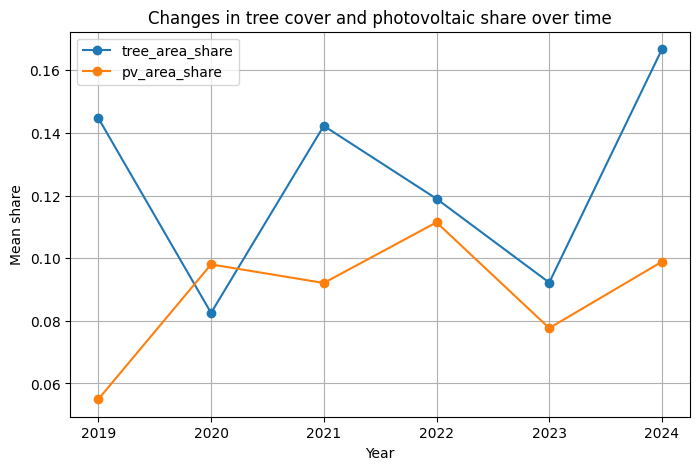

In [175]:
df.groupby('year')[['tree_area_share', 'pv_area_share']].mean().plot(figsize=(8,5),
    title="Changes in tree cover and photovoltaic share over time",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

 W analizowanym okresie udział instalacji fotowoltaicznych wykazuje ogólną tendencję wzrostową, z wyraźnym przyrostem w latach 2020–2022 oraz ponownym wzrostem w 2024 roku, przy jednoczesnym spadku w 2023 roku.Z kolei średni udział zadrzewienia wykazuje dużą zmienność z roku na rok. Nie zaobserwowano systematycznego, trwałego spadku zadrzewienia przy wzroście paneli, co  wstępnie sugeruje brak jednoznacznej zależności.

In [176]:
df['delta_tree'] = df.groupby('godlo')['tree_area_share'].diff()
df['delta_pv']   = df.groupby('godlo')['pv_area_share'].diff()

df[['delta_tree','delta_pv']].corr()

,delta_tree,delta_pv
delta_tree,1.000000,-0.056051
delta_pv,-0.056051,1.000000


Powyższy kod pozwala na stwierdzenie, że w miejscach, gdzie pojawiło się PV, lata z większym przyrostem PV wiążą się w bardzo małym stopniu z większym spadkiem drzew. Wskazuje na to mały ujemny współczynnik korelacji równy -0.056.

#### Analiza before-after

Analiz ta ma na celu sprawdzenie jak zmieniło się zadrzewienie w tym samym miejscu(dla tego samego kafelka)po pojawieniu się paneli PV w porównaniu do okresu przed.

In [177]:
summary = (
    df
    .groupby(['godlo','post_pv'])['tree_area_share']
    .mean()
    .reset_index()
)

summary.head()

,godlo,post_pv,tree_area_share
0,-34-49-B-c-4-4_10,True,0.010026
1,-34-49-B-c-4-4_101,False,0.096922
2,-34-49-B-c-4-4_101,True,0.105039
3,-34-49-B-c-4-4_114,False,0.746133
4,-34-49-B-c-4-4_114,True,0.753422


In [178]:
delta = summary.pivot(index='godlo', columns='post_pv', values='tree_area_share')
delta = delta.dropna(subset=[False, True])  


delta['delta_tree'] = delta[True] - delta[False]
delta.head()

post_pv,False,True,delta_tree
godlo,,,
-34-49-B-c-4-4_101,0.096922,0.105039,0.008117
-34-49-B-c-4-4_114,0.746133,0.753422,0.007289
-34-49-B-c-4-4_115,0.034395,0.047070,0.012676
-34-49-B-c-4-4_116,0.247946,0.312572,0.064626
-34-49-B-c-4-4_128,0.465250,0.662305,0.197055


Na początku liczmy średni udział zadrzewienia osobno dla każdego kafelka przed i po pojawieniu się panela. Następnie obliczamy różnicę o ile zmienił się udział zadrzewienia PO pojawieniu się PV względem okresu PRZED.

In [179]:
delta.describe()

post_pv,False,True,delta_tree
count,9810.000000,9810.000000,9810.000000
mean,0.135174,0.142622,0.007448
std,0.191948,0.190969,0.093387
min,0.000000,0.000000,-0.999971
25%,0.000273,0.002126,-0.003384
50%,0.057517,0.069362,0.000270
75%,0.185117,0.195449,0.024955
max,1.000000,0.999961,0.720000


Na podstawie wyników widać, że średni udział zadrzewienia po pojawieniu się instalacji fotowoltaicznych był nieznacznie wyższy niż w okresie wcześniejszym (średnia różnica +0.007). Różnica między medianą bliska 0 wskazuje, że w przeciętym kafelku poziom zadrzewienia nie uległ istotnej zmianie.

(array([3.400e+01, 7.000e+00, 8.000e+00, 2.400e+01, 1.390e+02, 7.503e+03,
        1.942e+03, 9.400e+01, 5.200e+01, 7.000e+00]),
 array([-0.9999707 , -0.82797363, -0.65597656, -0.48397949, -0.31198242,
        -0.13998535,  0.03201172,  0.20400879,  0.37600586,  0.54800293,
         0.72      ]),
 <BarContainer object of 10 artists>)

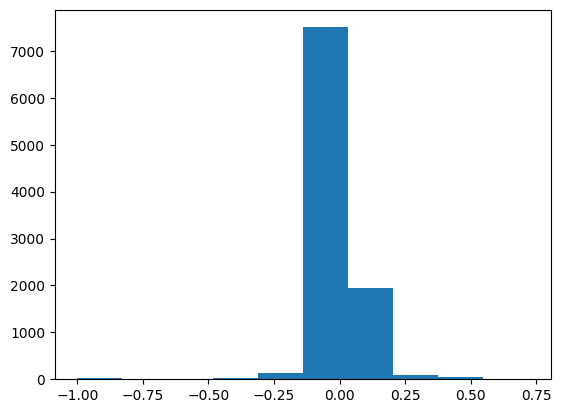

In [180]:
plt.hist(delta["delta_tree"], bins=10)

Histogram pokazuje, że większość kafelków ma zmiane zadrzewienia bliską 0.

#### DID (Difference-in-Differences)

Dodatkowa analiza DID ma na celu sprawdzenie czy zmiana zadrzewienia po pojawieniu się paneli różni się od zmiany, która zajdzie dla obszarów, gdzie PV nigdy nie powstało. Pozwoli to na weryfikacje czy redukcja lub przyrost drzew jest ściśle powiązany z panelami słonczenymi, czy zależy jednak od innych czynników zewnętrznych.


In [181]:
df_did= df_merged.copy()
df_did['has_pv'] = (
    df_did.groupby('godlo')['pv_area_share']
    .transform('max') > 0
)

df_did['has_pv'] = df_did['has_pv'].astype(int)
df_did[['godlo','has_pv']].drop_duplicates().head()

,godlo,has_pv
0,-34-50-C-c-3-1_88,1
1,-34-62-A-b-1-3_54,1
2,-34-49-D-d-2-3_172,1
3,-34-62-A-b-3-1_157,0
4,-34-50-D-c-3-2_65,1


Na początku dzielimy dane na te, które przynajmniej w jednym roku zobserowawno panele oraz na te, które nigdy ich nie miały. Kolejnym krokiem jest ustalenie średniego roku instalacji paneli, który będzie punktem odniesienia przy obliczaniu różnicy zadrzewienia dla każdej z grup.


In [182]:
post_year = 2022

df_did['post'] = (df_did['year'] >= post_year).astype(int)

df_did[['year','post']].drop_duplicates().sort_values('year')

,year,post
5,2019,0
0,2020,0
1,2021,0
2,2022,1
4,2023,1
3,2024,1


In [183]:
pre_pv = df_did[df_did['year'] < post_year]

pre_means = (
    pre_pv
    .groupby(['year','has_pv'])['tree_area_share']
    .mean()
    .unstack()
)

pre_means

has_pv,0,1
year,,
2019,0.530156,0.144730
2020,0.443225,0.082547
2021,0.523234,0.142258


Następnie obliczena jest średnia powierzchnia zajmowana przez drzewa dla lat przed rokiem granicznym (uznawanym za rok powstania pv).

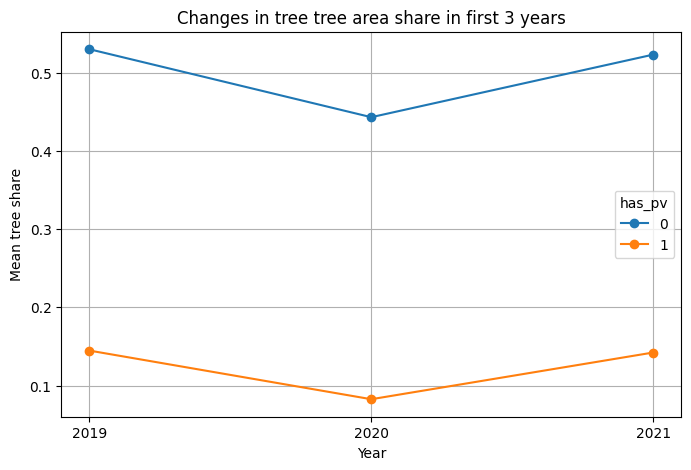

In [184]:
pre_means.plot(figsize=(8,5),title="Changes in tree tree area share in first 3 years",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean tree share")
plt.grid(True)
plt.xticks(pre_means.index)
plt.show()


Analiza trendów w okresie przed pojawieniem  instalacji fotowoltaicznych wskazuje na zbliżoną dynamikę zmian udziału zadrzewienia w grupie traktowanej i kontrolnej, co wspiera zasadność zastosowania analizy difference-in-differences

In [185]:
df_did['post_pv'] = (df_did['year'] >= post_year).astype(int)

did_model = smf.ols(
    'tree_area_share ~ has_pv * post_pv + year',
    data=df_did
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_did['godlo']}
)

print(did_model.summary())


                            OLS Regression Results                            
Dep. Variable:        tree_area_share   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     2914.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:53:17   Log-Likelihood:                -39492.
No. Observations:              146250   AIC:                         7.899e+04
Df Residuals:                  146245   BIC:                         7.904e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -22.7386      0.524    -43.

Ostatnim krokiem jest uruchomienie modelu regresji liniowej metodą najmniejszych kwadratów w celu przeprowadzenia finalnej analizy difference-in-differences. Metoda ta ma na celu porównanie zmiany udziału powierzchni zadrzewionej przed i po 2022 roku w lokalizacjach z instalacjami PV oraz w grupie kontrolnej bez paneli. Kontroluje przy tym trend czasowy i uwzględnia zależność obserwacji w obrębie kafelków.

Na podstawie wyników widać, że nie ma istotnej statystycznie różnicy w zmianach udziału zadrzewienia po roku 2022 pomiędzy kafelkami z PV a kafelkami bez PV. Świadcza o tym wyniki has_pv:post_pv=-0.0010 oraz p-value=0.354.

Dodatkowo na podstawie has_pv = -0.3757, można stwierdzić, że kafelki, gdzie kiedykolwiek pojawiły się panele mają ogólnie mniejszy udział drzew niż obszary bez pv.

Wynik post_pv = -0.0307 wskazuje, że średni udział zadrzewienia spadł we wszystkich kafelkach (z i bez pv).

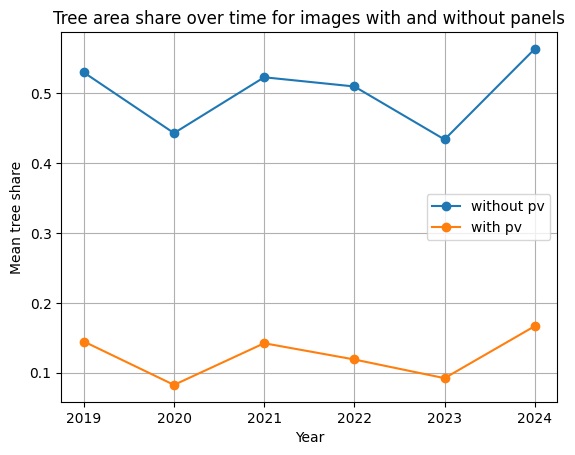

In [186]:
df_did.groupby(['year','has_pv'])['tree_area_share'].mean().unstack().plot(marker='o', 
title='Tree area share over time for images with and without panels')
plt.xlabel("Year")
plt.ylabel("Mean tree share")
plt.grid(True)
plt.legend(labels=['without pv', "with pv"])
plt.show()

Wyniki analizy nie wskazują na istnienie istotnego, dodatkowego wpływu instalacji fotowoltaicznych na zmiany zadrzewienia ponad obserwowany ogólny trend czasowy.

#### Lag analysis

Próba odpowiedzi na pytanie: Czy PV z poprzedniego roku jest związane z obecnym poziomem zadrzewienia?

In [187]:
df_lag = df_did.copy()
df_lag['pv_lag1'] = df_lag.groupby('godlo')['pv_area_share'].shift(1)
df_lag = df_lag.dropna(subset=['tree_area_share', 'pv_lag1', 'year', 'godlo'])


In [188]:
lag_model = smf.ols(
    'tree_area_share ~ pv_lag1 + year',
    data=df_lag
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_lag['godlo']}
)

print(lag_model.summary())

                            OLS Regression Results                            
Dep. Variable:        tree_area_share   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     1853.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:53:17   Log-Likelihood:                 12679.
No. Observations:               27838   AIC:                        -2.535e+04
Df Residuals:                   27835   BIC:                        -2.533e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.3675      0.989     -4.415      0.0

Otrzymany wynik pv_lag1=-0.1931 oraz p-value=0 wskazuje, że można zaobserwować statystyczne powiązanie wyższego udziału PV w poprzednim roku y z niższym poziomem zadrzewienia w roku następnym.